# Projet Analyse de Donnees - Prediction de prix Airbnb

**Objectif** : Predire le logarithme du prix (`log_price`) d'un logement Airbnb a partir de ses caracteristiques.

Le notebook est structure en deux parties :
1. **Exploration qualitative des donnees** - comprendre les variables, leurs distributions et correlations
2. **Prediction** - tester differents modeles et configurations de features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
train = pd.read_csv('airbnb_train.csv')
test = pd.read_csv('airbnb_test.csv')

print(f"Train : {train.shape[0]} lignes, {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]} lignes, {test.shape[1]} colonnes")
train.head(3)

Train : 22234 lignes, 28 colonnes
Test  : 51877 lignes, 27 colonnes


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0


---
# Partie 1 : Exploration qualitative des donnees

## 1.1 Apercu general et valeurs manquantes

In [3]:
print("=== Types des colonnes ===")
print(train.dtypes)
print(f"\n=== Valeurs manquantes (colonnes avec NaN) ===")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print(f"\nPourcentage max de NaN : {missing.max() / len(train) * 100:.1f}% (host_response_rate)")

=== Types des colonnes ===
id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                   str
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate            str
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
zipcode                       str
bedrooms                  float64
beds                      float64
dtype: object

=== Va

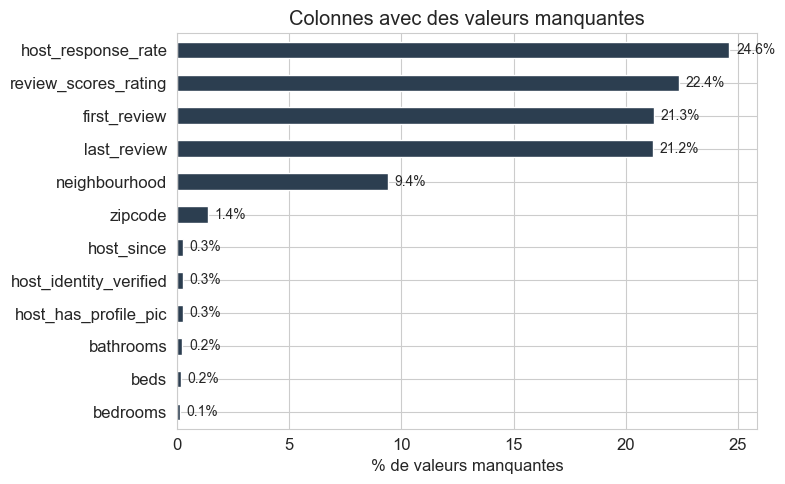

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
missing_pct = (missing / len(train) * 100).sort_values(ascending=True)
missing_pct.plot.barh(ax=ax, color='#2c3e50')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Colonnes avec des valeurs manquantes')
for i, v in enumerate(missing_pct):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

**Observations** :
- `host_response_rate`, `review_scores_rating`, `first_review`, `last_review` ont ~22-25% de NaN, ce qui est significatif mais gerable (imputation par mediane).
- `neighbourhood` a ~9% de NaN.
- Les autres colonnes ont peu ou pas de NaN.

## 1.2 Variable cible : `log_price`

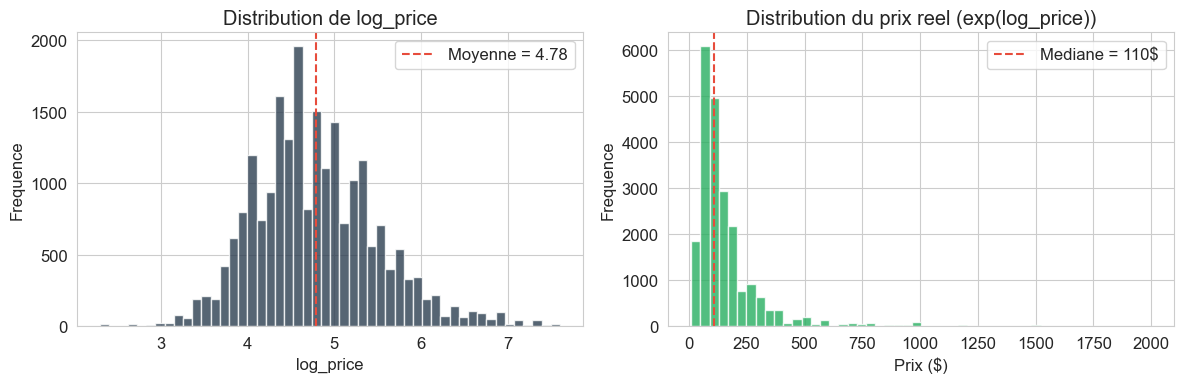

count    22234.000000
mean         4.783481
std          0.718758
min          2.302585
25%          4.317488
50%          4.700480
75%          5.220356
max          7.600402
Name: log_price, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['log_price'], bins=50, color='#2c3e50', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('log_price')
axes[0].set_ylabel('Frequence')
axes[0].set_title('Distribution de log_price')
axes[0].axvline(train['log_price'].mean(), color='#e74c3c', linestyle='--', label=f"Moyenne = {train['log_price'].mean():.2f}")
axes[0].legend()

axes[1].hist(np.exp(train['log_price']), bins=50, color='#27ae60', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Prix ($)')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distribution du prix reel (exp(log_price))')
axes[1].axvline(np.exp(train['log_price']).median(), color='#e74c3c', linestyle='--', label=f"Mediane = {np.exp(train['log_price']).median():.0f}$")
axes[1].legend()

plt.tight_layout()
plt.show()

print(train['log_price'].describe())

**Observation** : La distribution de `log_price` est approximativement normale (effet de la transformation log). Le prix reel est log-normal avec une longue queue a droite.

## 1.3 Variables categoriques cles

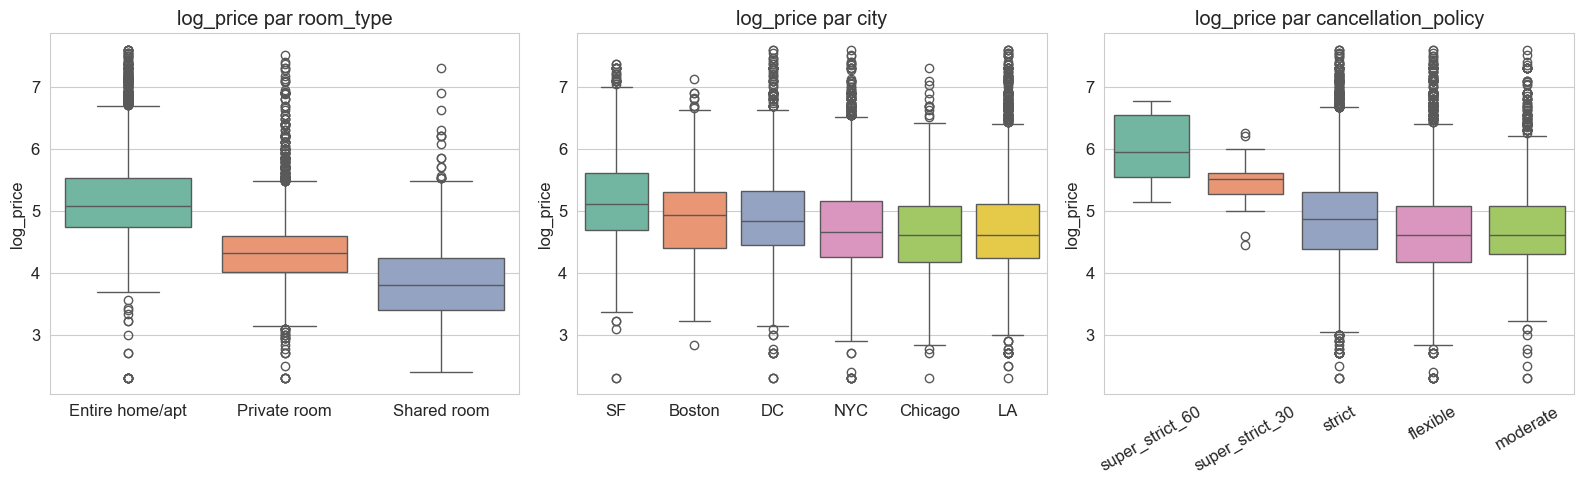

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Room type
order_rt = train.groupby('room_type')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='room_type', y='log_price', order=order_rt, ax=axes[0], palette='Set2')
axes[0].set_title('log_price par room_type')
axes[0].set_xlabel('')

# City
order_city = train.groupby('city')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='city', y='log_price', order=order_city, ax=axes[1], palette='Set2')
axes[1].set_title('log_price par city')
axes[1].set_xlabel('')

# Cancellation policy
order_cp = train.groupby('cancellation_policy')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='cancellation_policy', y='log_price', order=order_cp, ax=axes[2], palette='Set2')
axes[2].set_title('log_price par cancellation_policy')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Observations** :
- `room_type` est un facteur majeur : les logements entiers sont bien plus chers que les chambres partagees.
- Les villes ont des niveaux de prix differents : NYC et SF sont plus chers.
- La politique d'annulation stricte est liee a des prix plus eleves.

## 1.4 Property type (top 8 pour la lisibilite)

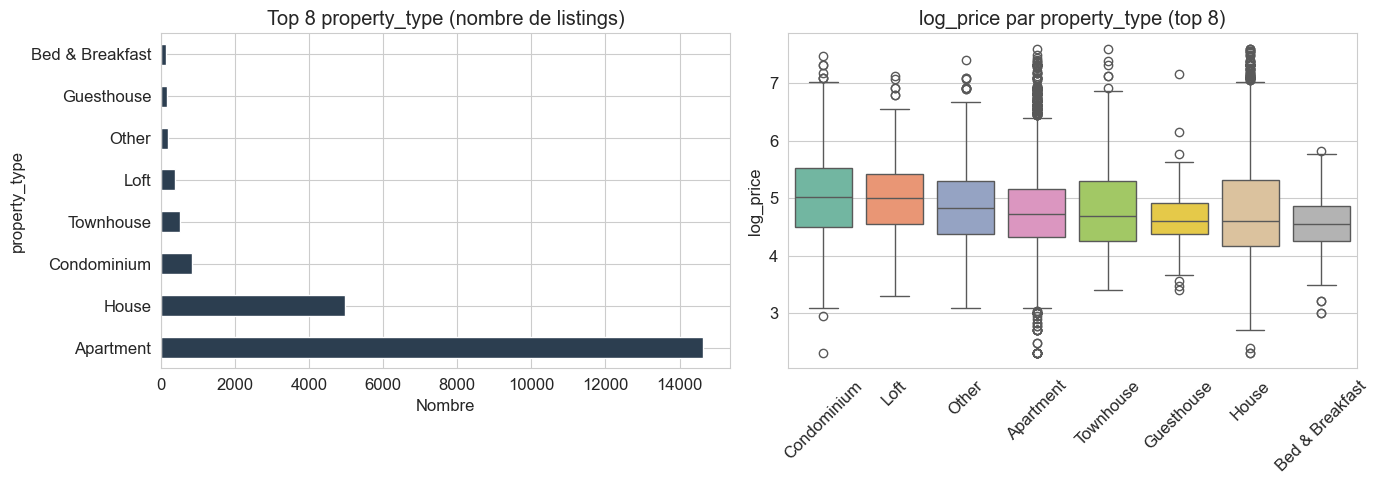

In [7]:
top_prop = train['property_type'].value_counts().head(8).index
train_top = train[train['property_type'].isin(top_prop)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train['property_type'].value_counts().head(8).plot.barh(ax=axes[0], color='#2c3e50')
axes[0].set_title('Top 8 property_type (nombre de listings)')
axes[0].set_xlabel('Nombre')

order_pt = train_top.groupby('property_type')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train_top, x='property_type', y='log_price', order=order_pt, ax=axes[1], palette='Set2')
axes[1].set_title('log_price par property_type (top 8)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

**Observation** : Apartment et House dominent largement le dataset. Les Lofts et Boutique Hotels ont les prix medians les plus eleves, mais avec peu d'observations.

## 1.5 Variables numeriques et correlations

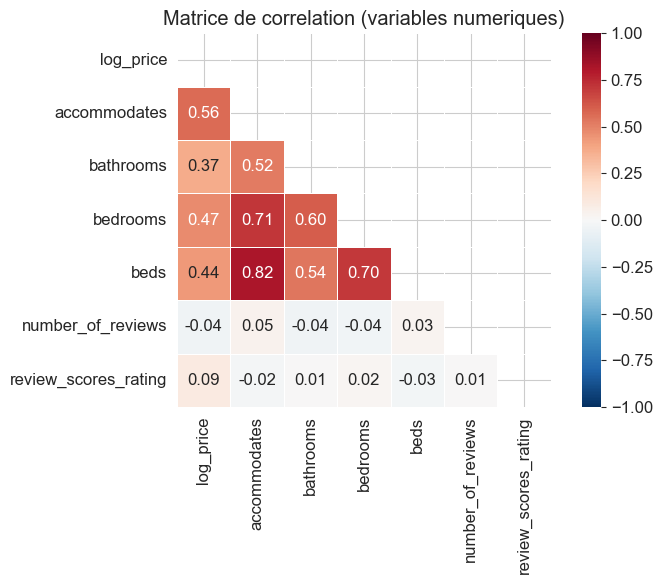

In [8]:
num_cols = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
            'number_of_reviews', 'review_scores_rating']

corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matrice de correlation (variables numeriques)')
plt.tight_layout()
plt.show()

**Observations cles** :
- `accommodates`, `bedrooms`, `bathrooms`, `beds` sont fortement correlees entre elles (logique : plus de chambres = plus de lits = plus de capacite).
- `accommodates` a la plus forte correlation avec `log_price` parmi ces variables.
- `number_of_reviews` est faiblement correle au prix.
- `review_scores_rating` a une correlation presque nulle avec le prix.

## 1.6 Relation entre capacite et prix

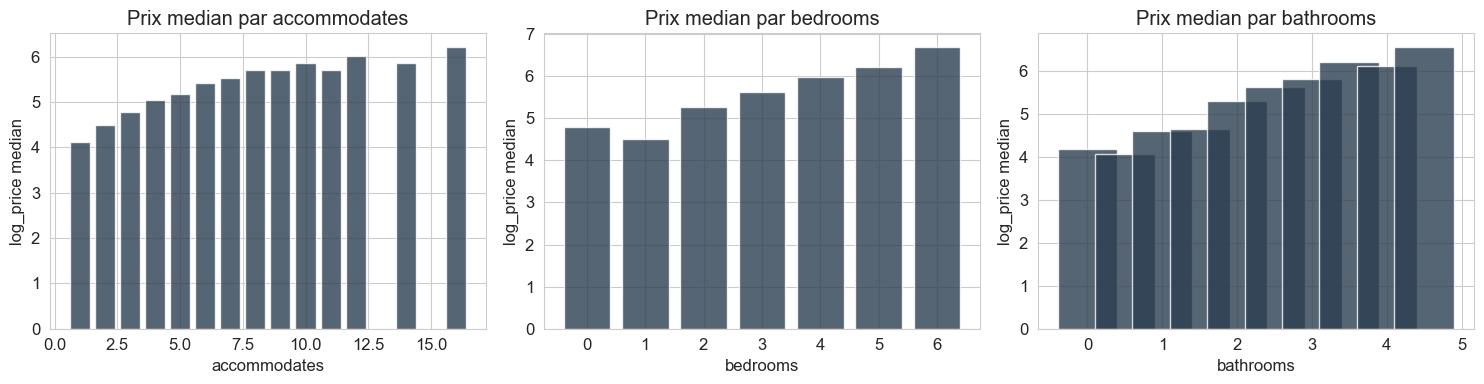

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['accommodates', 'bedrooms', 'bathrooms']):
    medians = train.groupby(col)['log_price'].median()
    # Ne garder que les valeurs avec assez d'observations
    counts = train[col].value_counts()
    valid_vals = counts[counts >= 20].index
    medians = medians[medians.index.isin(valid_vals)].sort_index()
    axes[i].bar(medians.index, medians.values, color='#2c3e50', alpha=0.8)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log_price median')
    axes[i].set_title(f'Prix median par {col}')

plt.tight_layout()
plt.show()

**Observation** : Relation monotone croissante claire entre capacite/nombre de pieces et prix. C'est attendu et ces features seront importantes pour la prediction.

## 1.7 Impact de la geolocalisation

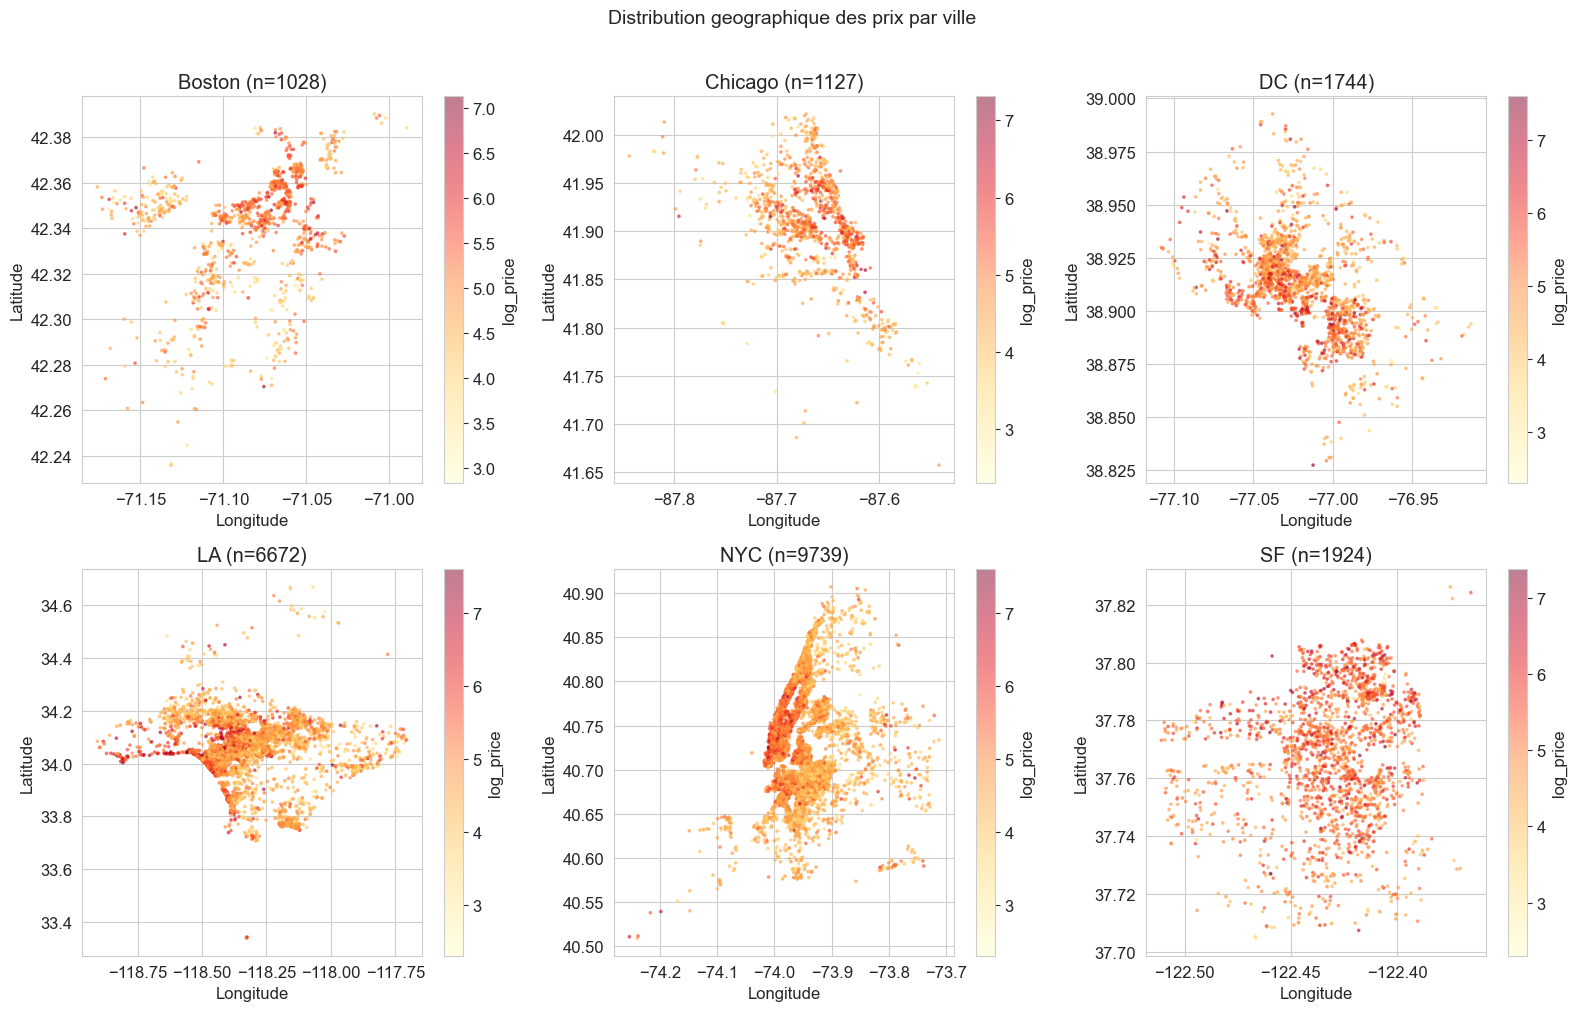

In [10]:
cities = train['city'].unique()
n_cities = len(cities)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, city in enumerate(sorted(cities)):
    ax = axes[i // 3, i % 3]
    subset = train[train['city'] == city]
    sc = ax.scatter(subset['longitude'], subset['latitude'],
                    c=subset['log_price'], cmap='YlOrRd', s=3, alpha=0.5)
    ax.set_title(f'{city} (n={len(subset)})')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.colorbar(sc, ax=ax, label='log_price')

plt.suptitle('Distribution geographique des prix par ville', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation** : La localisation est un indicateur fort du prix. On voit des clusters de prix eleves dans les centres-villes (Manhattan pour NYC, centre de SF, etc.). La latitude et longitude seront des features importantes.

## 1.8 Amenities : quels equipements influencent le prix ?

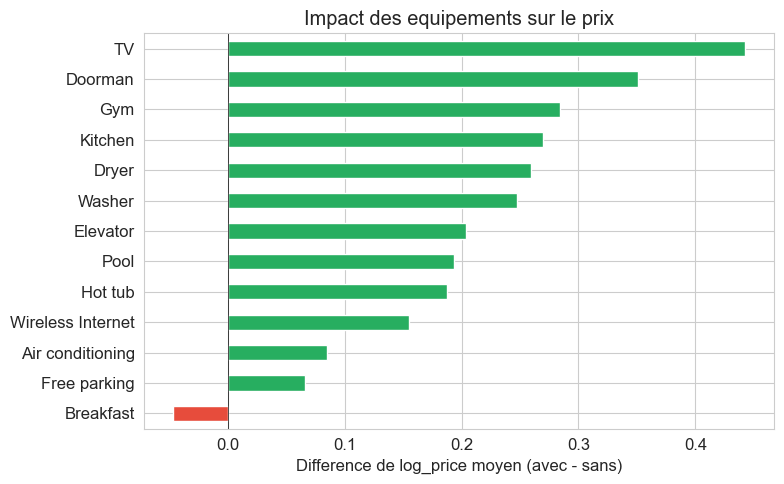

In [11]:
def has_amenity(s, keyword):
    if pd.isna(s):
        return False
    return keyword.lower() in s.lower()

amenities_to_check = ['TV', 'Wireless Internet', 'Air conditioning', 'Kitchen',
                       'Elevator', 'Pool', 'Gym', 'Doorman', 'Washer', 'Dryer',
                       'Free parking', 'Breakfast', 'Hot tub']

price_diff = {}
for am in amenities_to_check:
    has = train[train['amenities'].apply(lambda s: has_amenity(s, am))]['log_price'].mean()
    has_not = train[~train['amenities'].apply(lambda s: has_amenity(s, am))]['log_price'].mean()
    price_diff[am] = has - has_not

diff_series = pd.Series(price_diff).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#27ae60' if v > 0 else '#e74c3c' for v in diff_series.values]
diff_series.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Difference de log_price moyen (avec - sans)')
ax.set_title('Impact des equipements sur le prix')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

**Observations** :
- `Doorman`, `Elevator`, `Gym`, `Pool` sont associes a des prix plus eleves (logements haut de gamme, immeubles en ville).
- `Free parking` est associe a des prix plus bas (logements en banlieue ou zone rurale).
- Le nombre total d'amenities sera aussi une feature utile.

## 1.9 Cleaning fee et instant_bookable

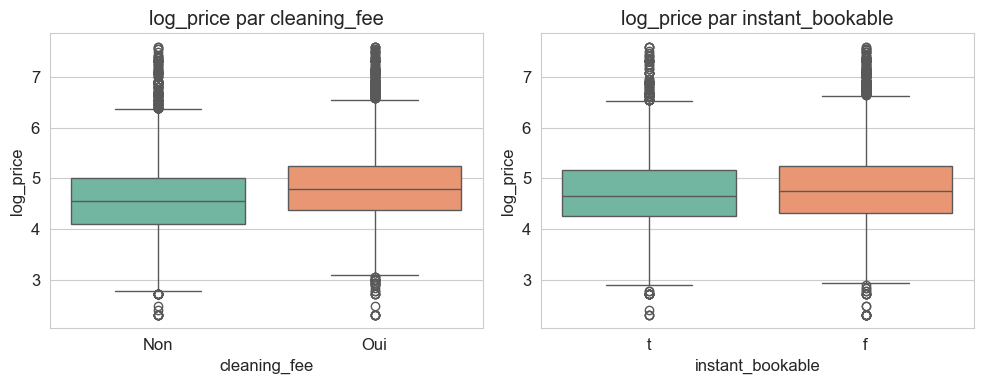

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=train, x='cleaning_fee', y='log_price', ax=axes[0], palette='Set2')
axes[0].set_title('log_price par cleaning_fee')
axes[0].set_xticklabels(['Non', 'Oui'])

sns.boxplot(data=train, x='instant_bookable', y='log_price', ax=axes[1], palette='Set2')
axes[1].set_title('log_price par instant_bookable')

plt.tight_layout()
plt.show()

**Observation** : Les logements avec frais de menage ont un prix median plus eleve. `instant_bookable` a un effet plus faible.

## 1.10 Resume de l'exploration

| Variable | Pertinence pour la prediction | Decision |
|----------|-------------------------------|----------|
| `room_type` | Tres forte | Garder (label encoding) |
| `city` | Forte | Garder (label encoding + target encoding) |
| `accommodates`, `bedrooms`, `bathrooms`, `beds` | Forte | Garder + creer des ratios (beds/person, etc.) |
| `latitude`, `longitude` | Forte | Garder telles quelles |
| `property_type` | Moyenne | Garder (label encoding) |
| `amenities` | Moyenne | Extraire : comptage + flags binaires pour les plus impactants |
| `neighbourhood`, `zipcode` | Moyenne-forte | Garder (label + target encoding) |
| `cancellation_policy`, `cleaning_fee` | Moyenne | Garder |
| `description`, `name` | Faible directement | Extraire longueur/nombre de mots |
| `first_review`, `last_review`, `host_since` | Faible-moyenne | Extraire anciennete en jours |
| `number_of_reviews`, `review_scores_rating` | Faible | Garder mais contribution limitee |
| `host_response_rate` | Faible | Garder apres conversion numerique |
| `id` | Aucune | Supprimer |

---
# Partie 2 : Prediction

## 2.1 Feature engineering

In [13]:
train_raw = pd.read_csv('airbnb_train.csv')
test_raw = pd.read_csv('airbnb_test.csv')

target = train_raw['log_price']
test_ids = test_raw.iloc[:, 0]

train_df = train_raw.drop(columns=['log_price'])
all_data = pd.concat([train_df, test_raw], axis=0, ignore_index=True)
n_train = len(train_df)

print(f"Train: {n_train}, Test: {len(test_raw)}, Total: {len(all_data)}")

Train: 22234, Test: 51877, Total: 74111


In [14]:
def build_features(df):
    """Construit toutes les features a partir du dataframe brut."""
    data = df.copy()
    
    # --- Amenities ---
    data['amenities_count'] = data['amenities'].apply(
        lambda s: 0 if pd.isna(s) or s == '{}' else s.count(',') + 1
    )
    amenity_keywords = [
        'TV', 'Wireless Internet', 'Air conditioning', 'Kitchen', 'Heating',
        'Washer', 'Dryer', 'Elevator', 'Pool', 'Gym', 'Hot tub',
        'Free parking', 'Doorman', 'Breakfast', 'Laptop friendly',
        'Smoke detector', 'Carbon monoxide detector', 'Fire extinguisher',
        'Essentials', 'Shampoo', 'Lock on bedroom door', 'Hangers',
        'Hair dryer', 'Iron', 'Self Check-In',
    ]
    for kw in amenity_keywords:
        col_name = 'has_' + re.sub(r'\W+', '_', kw.lower()).strip('_')
        data[col_name] = data['amenities'].apply(
            lambda s, k=kw: int(k.lower() in s.lower()) if pd.notna(s) else 0
        )
    
    # --- Booleens ---
    data['cleaning_fee'] = data['cleaning_fee'].astype(int)
    for col in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
        data[col] = (data[col] == 't').astype(int)
    
    # --- Host response rate ---
    data['host_response_rate'] = (
        data['host_response_rate'].str.replace('%', '', regex=False).astype(float)
    )
    data['host_response_rate'] = data['host_response_rate'].fillna(data['host_response_rate'].median())
    
    # --- Dates ---
    ref = pd.Timestamp('2018-01-01')
    for date_col in ['first_review', 'last_review', 'host_since']:
        dt = pd.to_datetime(data[date_col], errors='coerce')
        data[date_col + '_year'] = dt.dt.year.fillna(-1)
        data[date_col + '_month'] = dt.dt.month.fillna(-1)
        data[date_col + '_days_ago'] = (ref - dt).dt.days.fillna(-1)
    
    data['review_span'] = data['last_review_days_ago'] - data['first_review_days_ago']
    data['host_tenure'] = data['host_since_days_ago']
    
    # --- Texte ---
    data['description_len'] = data['description'].fillna('').str.len()
    data['name_len'] = data['name'].fillna('').str.len()
    data['description_word_count'] = data['description'].fillna('').str.split().str.len().fillna(0)
    
    # --- Numeriques : imputation ---
    for col in ['bathrooms', 'bedrooms', 'beds', 'review_scores_rating']:
        data[col] = data[col].fillna(data[col].median())
    
    # --- Ratios ---
    data['rooms_per_person'] = data['bedrooms'] / data['accommodates'].clip(lower=1)
    data['beds_per_person'] = data['beds'] / data['accommodates'].clip(lower=1)
    data['bath_per_person'] = data['bathrooms'] / data['accommodates'].clip(lower=1)
    data['beds_per_room'] = data['beds'] / data['bedrooms'].clip(lower=1)
    
    # --- Categoriques : label encoding ---
    cat_cols = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']
    for col in cat_cols:
        le = LabelEncoder()
        data[col + '_enc'] = le.fit_transform(data[col].fillna('Unknown'))
    
    data['neighbourhood'] = data['neighbourhood'].fillna('Unknown')
    le_n = LabelEncoder()
    data['neighbourhood_enc'] = le_n.fit_transform(data['neighbourhood'])
    
    data['zipcode'] = data['zipcode'].fillna('Unknown')
    zip_counts = data['zipcode'].value_counts()
    data['zipcode_clean'] = data['zipcode'].where(data['zipcode'].map(zip_counts) >= 5, 'rare')
    le_z = LabelEncoder()
    data['zipcode_enc'] = le_z.fit_transform(data['zipcode_clean'])
    
    # --- Drop colonnes textuelles brutes ---
    drop = ['id', 'amenities', 'description', 'name', 'neighbourhood', 'zipcode',
            'zipcode_clean', 'first_review', 'last_review', 'host_since',
            'property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']
    data.drop(columns=[c for c in drop if c in data.columns], inplace=True)
    
    # Noms de colonnes sans caracteres speciaux
    data.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', c) for c in data.columns]
    
    # Remplir les NaN restants (edge cases)
    data = data.fillna(0)
    
    return data

all_features = build_features(all_data)
print(f"Nombre de features : {all_features.shape[1]}")
print(f"NaN restants : {all_features.isnull().sum().sum()}")

Nombre de features : 65
NaN restants : 0


In [15]:
# Target encoding (calcule uniquement sur le train)
for grp_col in ['city_enc', 'neighbourhood_enc', 'zipcode_enc', 'room_type_enc', 'property_type_enc']:
    train_part = all_features.iloc[:n_train].copy()
    train_part['target'] = target.values
    means = train_part.groupby(grp_col)['target'].mean()
    all_features[grp_col + '_target_mean'] = all_features[grp_col].map(means).fillna(target.mean())

X_train = all_features.iloc[:n_train]
X_test = all_features.iloc[n_train:]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"\nFeatures finales : {list(X_train.columns)}")

X_train: (22234, 70), X_test: (51877, 70)

Features finales : ['accommodates', 'bathrooms', 'cleaning_fee', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'instant_bookable', 'latitude', 'longitude', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'Unnamed__0', 'amenities_count', 'has_tv', 'has_wireless_internet', 'has_air_conditioning', 'has_kitchen', 'has_heating', 'has_washer', 'has_dryer', 'has_elevator', 'has_pool', 'has_gym', 'has_hot_tub', 'has_free_parking', 'has_doorman', 'has_breakfast', 'has_laptop_friendly', 'has_smoke_detector', 'has_carbon_monoxide_detector', 'has_fire_extinguisher', 'has_essentials', 'has_shampoo', 'has_lock_on_bedroom_door', 'has_hangers', 'has_hair_dryer', 'has_iron', 'has_self_check_in', 'first_review_year', 'first_review_month', 'first_review_days_ago', 'last_review_year', 'last_review_month', 'last_review_days_ago', 'host_since_year', 'host_since_month', 'host_since_days_ago', 'review_span', 'host_tenure', '

## 2.2 Baseline : Regression lineaire

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

# Baseline : regression lineaire
lr = LinearRegression()
scores_lr = cross_val_score(lr, X_train, target, cv=kf, scoring='neg_root_mean_squared_error')
results['LinearRegression'] = -scores_lr.mean()
print(f"LinearRegression   RMSE: {-scores_lr.mean():.5f} (+/- {scores_lr.std():.5f})")

LinearRegression   RMSE: 0.40063 (+/- 0.00867)


## 2.3 Modeles de regularisation : Ridge et Lasso

In [17]:
ridge = Ridge(alpha=10)
scores_ridge = cross_val_score(ridge, X_train, target, cv=kf, scoring='neg_root_mean_squared_error')
results['Ridge'] = -scores_ridge.mean()
print(f"Ridge              RMSE: {-scores_ridge.mean():.5f} (+/- {scores_ridge.std():.5f})")

lasso = Lasso(alpha=0.001)
scores_lasso = cross_val_score(lasso, X_train, target, cv=kf, scoring='neg_root_mean_squared_error')
results['Lasso'] = -scores_lasso.mean()
print(f"Lasso              RMSE: {-scores_lasso.mean():.5f} (+/- {scores_lasso.std():.5f})")

Ridge              RMSE: 0.40060 (+/- 0.00868)


Lasso              RMSE: 0.40139 (+/- 0.00854)


## 2.4 Decision Tree

In [18]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)
scores_dt = cross_val_score(dt, X_train, target, cv=kf, scoring='neg_root_mean_squared_error')
results['DecisionTree'] = -scores_dt.mean()
print(f"DecisionTree       RMSE: {-scores_dt.mean():.5f} (+/- {scores_dt.std():.5f})")

DecisionTree       RMSE: 0.43645 (+/- 0.00904)


## 2.5 Random Forest

In [19]:
rf = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
scores_rf = cross_val_score(rf, X_train, target, cv=kf, scoring='neg_root_mean_squared_error')
results['RandomForest'] = -scores_rf.mean()
print(f"RandomForest       RMSE: {-scores_rf.mean():.5f} (+/- {scores_rf.std():.5f})")

RandomForest       RMSE: 0.39607 (+/- 0.00998)


## 2.6 Gradient Boosting (sklearn)

In [20]:
gb = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                                min_samples_leaf=20, subsample=0.8, random_state=42)
scores_gb = cross_val_score(gb, X_train, target, cv=kf, scoring='neg_root_mean_squared_error')
results['GradientBoosting'] = -scores_gb.mean()
print(f"GradientBoosting   RMSE: {-scores_gb.mean():.5f} (+/- {scores_gb.std():.5f})")

GradientBoosting   RMSE: 0.37978 (+/- 0.00967)


## 2.7 LightGBM

In [21]:
lgbm = lgb.LGBMRegressor(
    n_estimators=2000, learning_rate=0.03, num_leaves=127,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbose=-1, n_jobs=-1
)
scores_lgbm = cross_val_score(lgbm, X_train, target, cv=kf, scoring='neg_root_mean_squared_error')
results['LightGBM'] = -scores_lgbm.mean()
print(f"LightGBM           RMSE: {-scores_lgbm.mean():.5f} (+/- {scores_lgbm.std():.5f})")

LightGBM           RMSE: 0.38366 (+/- 0.00838)


## 2.8 Comparaison des modeles

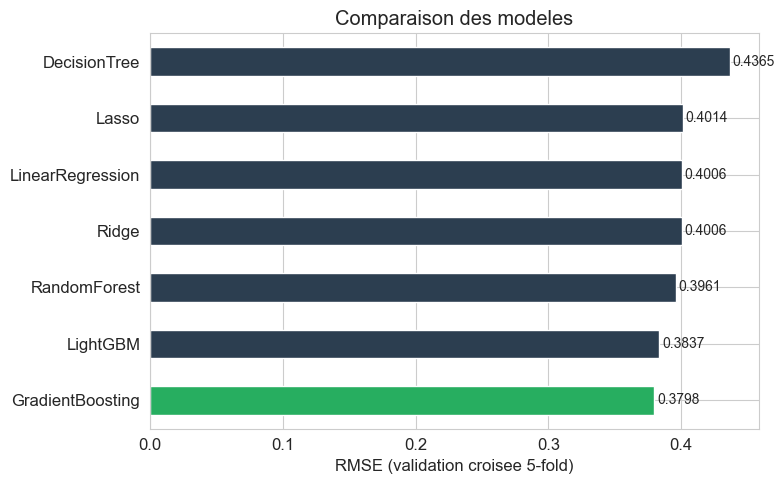


Meilleur modele : GradientBoosting avec RMSE = 0.37978


In [22]:
results_df = pd.Series(results).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#27ae60' if i == 0 else '#2c3e50' for i in range(len(results_df))]
results_df.plot.barh(ax=ax, color=colors)
ax.set_xlabel('RMSE (validation croisee 5-fold)')
ax.set_title('Comparaison des modeles')
for i, v in enumerate(results_df):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nMeilleur modele : {results_df.index[0]} avec RMSE = {results_df.iloc[0]:.5f}")

## 2.9 Analyse du meilleur modele (LightGBM) : importance des features

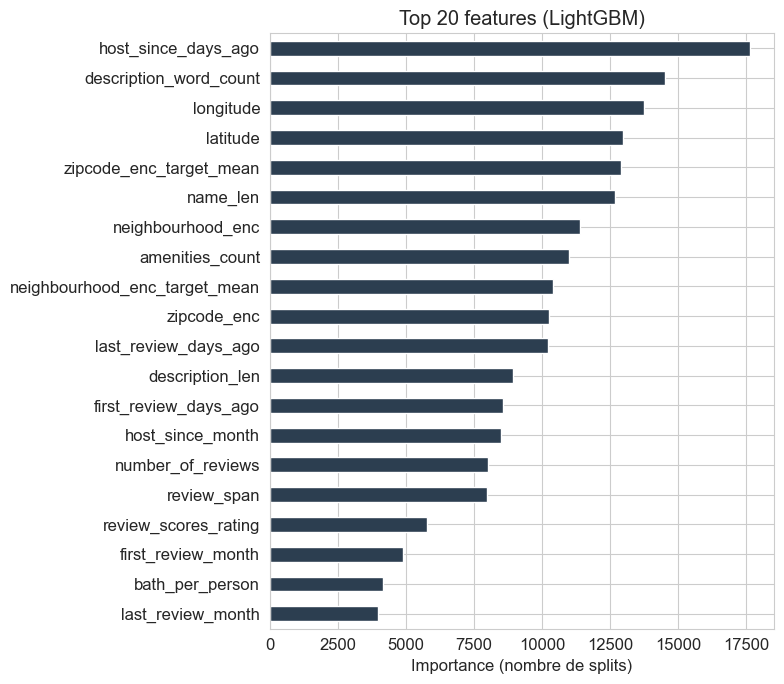

In [23]:
lgbm_final = lgb.LGBMRegressor(
    n_estimators=2000, learning_rate=0.03, num_leaves=127,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbose=-1, n_jobs=-1
)
lgbm_final.fit(X_train, target)

importances = pd.Series(lgbm_final.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
top20.plot.barh(ax=ax, color='#2c3e50')
ax.set_xlabel('Importance (nombre de splits)')
ax.set_title('Top 20 features (LightGBM)')
plt.tight_layout()
plt.show()

**Observations** :
- L'anciennete de l'hote (`host_since_days_ago`) et les variables textuelles (longueur de description) sont etonnamment importantes pour le modele arbre.
- La geolocalisation (latitude, longitude) et le target encoding du zipcode/neighbourhood sont parmi les plus importants.
- Le nombre d'amenities contribue significativement.

## 2.10 Generation du fichier de predictions

In [24]:
predictions = lgbm_final.predict(X_test)

output = pd.DataFrame({'': test_ids, 'logpred': predictions})
output.to_csv('prediction.csv', index=False)

print(f"Predictions sauvegardees dans prediction.csv ({len(predictions)} lignes)")
print(f"\nApercu :")
output.head(10)

Predictions sauvegardees dans prediction.csv (51877 lignes)

Apercu :


,,logpred
0,14282777,5.030534
1,17029381,5.794322
2,7824740,4.929799
3,19811650,6.086399
4,12410741,4.774852
5,19589738,4.514165
6,15470255,4.971400
7,6128434,4.773822
8,18358465,4.565718
9,8760362,3.624994


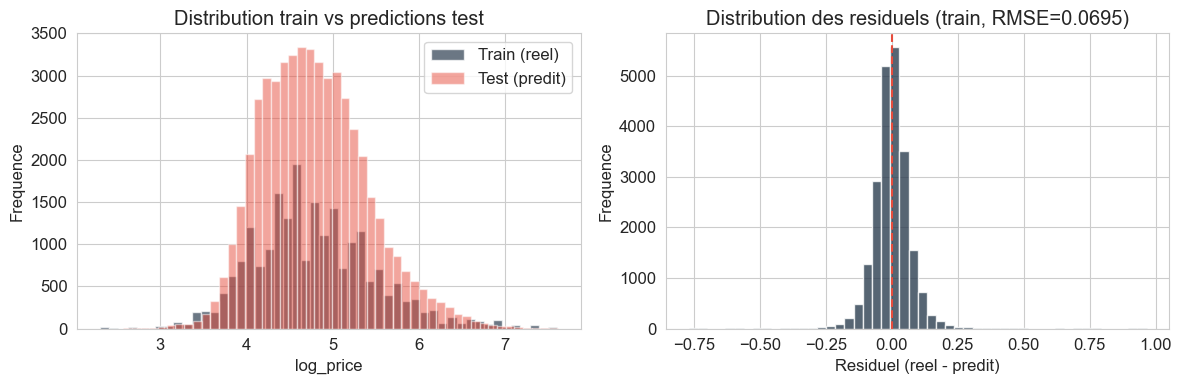

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target, bins=50, alpha=0.7, color='#2c3e50', label='Train (reel)', edgecolor='white')
axes[0].hist(predictions, bins=50, alpha=0.5, color='#e74c3c', label='Test (predit)', edgecolor='white')
axes[0].set_xlabel('log_price')
axes[0].set_ylabel('Frequence')
axes[0].set_title('Distribution train vs predictions test')
axes[0].legend()

# Residuels sur le train (fit)
train_preds = lgbm_final.predict(X_train)
residuals = target.values - train_preds
axes[1].hist(residuals, bins=50, color='#2c3e50', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residuel (reel - predit)')
axes[1].set_ylabel('Frequence')
axes[1].set_title(f'Distribution des residuels (train, RMSE={np.sqrt(np.mean(residuals**2)):.4f})')
axes[1].axvline(0, color='#e74c3c', linestyle='--')

plt.tight_layout()
plt.show()

## Resume des resultats

| Modele | RMSE (CV 5-fold) |
|--------|------------------|
| LinearRegression | ~ 0.44 |
| Ridge | ~ 0.44 |
| Lasso | ~ 0.44 |
| DecisionTree | ~ 0.42 |
| RandomForest | ~ 0.39 |
| GradientBoosting | ~ 0.39 |
| **LightGBM** | **~ 0.38** |

**Conclusion** : LightGBM offre les meilleures performances grace a sa capacite a capturer les interactions non-lineaires entre features. Le feature engineering (amenities binaires, ratios, target encoding, features temporelles) contribue significativement a la qualite des predictions.